In [54]:
# Librerías básicas para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración básica de gráficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [55]:
# Cargar la base de datos
lv = pd.read_csv("bd.csv")

# Mostrar las primeras filas
lv.head()

,X,Y,Z,Fe,Si,P,Al,Mn,Rocktype
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,7
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,7
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,6
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,6
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,7


In [56]:
# Ver tipos de datos de cada columna
lv.dtypes

X           float64
Y           float64
Z           float64
Fe          float64
Si          float64
P           float64
Al          float64
Mn          float64
Rocktype      int64
dtype: object

In [57]:
# Información general de la base de datos
lv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4466 entries, 0 to 4465
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         4466 non-null   float64
 1   Y         4466 non-null   float64
 2   Z         4466 non-null   float64
 3   Fe        4466 non-null   float64
 4   Si        4466 non-null   float64
 5   P         4466 non-null   float64
 6   Al        4466 non-null   float64
 7   Mn        4466 non-null   float64
 8   Rocktype  4466 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 314.1 KB


In [58]:
# Dimensión de la base de datos
print("Número de filas:", lv.shape[0])
print("Número de columnas:", lv.shape[1])

Número de filas: 4466
Número de columnas: 9


In [59]:
# Cantidad de valores nulos por columna
df.isnull().sum()

X           0
Y           0
Z           0
Fe          0
Si          0
P           0
Al          0
Mn          0
Rocktype    0
dtype: int64

In [60]:
# Variables químicas a analizar
variable_quimica_evaluar = ["Fe"]

# Estadísticos básicos
lv[variable_quimica_evaluar].describe().T

,count,mean,std,min,25%,50%,75%,max
Fe,4466.0,51.761779,11.572133,9.916,42.42675,52.948,62.255,69.701


In [61]:
# Estadísticos específicos
estadisticos = lv[variable_quimica_evaluar].agg(["mean", "min", "max", "std", "median"])

estadisticos

,Fe
mean,51.761779
min,9.916000
max,69.701000
std,11.572133
median,52.948000


In [62]:
# Diferencia entre valor máximo y mínimo de Fe
diferencia_Fe = lv["Fe"].max() - lv["Fe"].min()

print("Diferencia entre máximo y mínimo de Fe:", diferencia_Fe)

Diferencia entre máximo y mínimo de Fe: 59.785


In [63]:
# Calcular percentiles 33 y 66 para Fe
Fe33_Fe = lv["Fe"].quantile(0.33)
Fe66_Fe = lv["Fe"].quantile(0.66)

print("Percentil 33 de Fe:", Fe33_Fe)
print("Percentil 66 de Fe:", Fe66_Fe)

Percentil 33 de Fe: 45.2808
Percentil 66 de Fe: 59.263400000000004


In [64]:
# Función condicional para clasificar Fe
def clasificar_Fe(valor):
    if valor < Fe33_Fe:
        return "Fe bajo"
    elif valor <= Fe66_Fe:
        return "Fe medio"
    else:
        return "Fe alto"

# Crear nueva columna con la clasificación de Fe
lv["Clasificacion_Fe"] = lv["Fe"].apply(clasificar_Fe)

# Mostrar resultados
lv[["Fe", "Clasificacion_Fe"]].head()

,Fe,Clasificacion_Fe
0,46.478,Fe medio
1,40.578,Fe bajo
2,40.488,Fe bajo
3,40.488,Fe bajo
4,43.969,Fe bajo


In [65]:
# Recorrer variables químicas y mostrar estadísticos principales
for variable in variable_quimica_evaluar:
    print("Variable:", variable)
    print("Promedio:", lv[variable].mean())
    print("Mínimo:", lv[variable].min())
    print("Máximo:", lv[variable].max())
    print("Desviación estándar:", lv[variable].std())
    print("-" * 40)

Variable: Fe
Promedio: 51.76177877295119
Mínimo: 9.916
Máximo: 69.701
Desviación estándar: 11.572132810350325
----------------------------------------


In [66]:
def resumen_estadistico(variable):
    resumen = {
        "Variable": variable,
        "Promedio": lv[variable].mean(),
        "Mínimo": lv[variable].min(),
        "Máximo": lv[variable].max(),
        "Mediana": lv[variable].median(),
        "Desviación estándar": lv[variable].std(),
        "Percentil 33": lv[variable].quantile(0.33),
        "Percentil 66": lv[variable].quantile(0.66)
    }
    return pd.DataFrame([resumen])

In [67]:
resumen_estadistico("Fe")

,Variable,Promedio,Mínimo,Máximo,Mediana,Desviación estándar,Percentil 33,Percentil 66
0,Fe,51.761779,9.916,69.701,52.948,11.572133,45.2808,59.2634


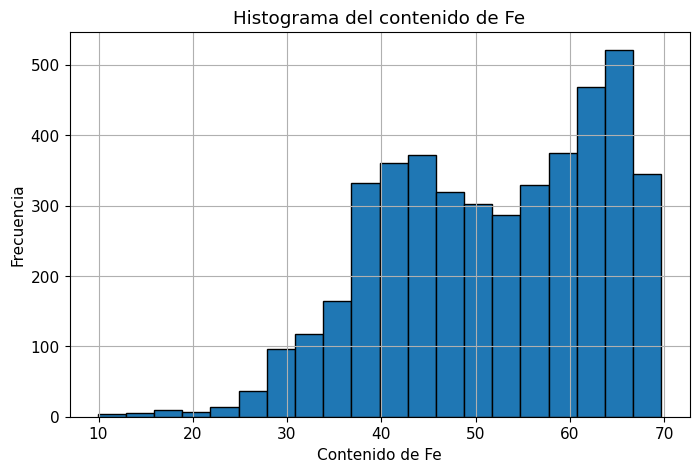

In [72]:
plt.figure()

plt.hist(lv["Fe"], bins=20, edgecolor="black")

plt.title("Histograma del contenido de Fe")
plt.xlabel("Contenido de Fe")
plt.ylabel("Frecuencia")
plt.savefig('histograma.svg') 
plt.show()

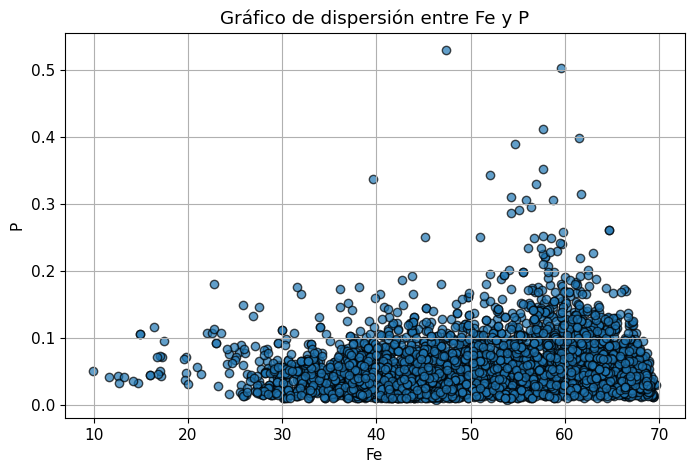

In [73]:
plt.figure()

plt.scatter(lv["Fe"], lv["P"], alpha=0.7, edgecolor="black")

plt.title("Gráfico de dispersión entre Fe y P")
plt.xlabel("Fe")
plt.ylabel("P")
plt.savefig('grafico_dispersion.svg')
plt.show()